# 15 - Late Fusion Transfer Learning (ResNet18 + FCNN - 4 Class)

**Tujuan:** Menggabungkan prediksi model CNN Transfer Learning (ResNet18) dan FCNN (unimodal landmark) menggunakan strategi Late Fusion berbasis weighted averaging untuk klasifikasi 4 kelas emosi.

**Strategi:**
- Load model CNN Transfer Learning dan FCNN yang sudah di-training (pre-trained) untuk 4 kelas
- Dapatkan probabilitas prediksi dari masing-masing model
- Gabungkan dengan weighted averaging: `fused = w * P_cnn_tl + (1-w) * P_fcnn`
- Cari bobot optimal `w` melalui grid search pada validation set
- Evaluasi pada test set menggunakan bobot optimal

**Catatan:** Late Fusion **tidak** melatih model baru - hanya menggabungkan output model yang sudah ada.

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNNTransfer, EmotionFCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_4class"
OUTPUT_DIR = PROJECT_ROOT / "models" / "4class" / "late_fusion_transfer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_CLASSES = 4
BATCH_SIZE = 32

EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_4class
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/late_fusion_transfer


## 2. Load Data

In [3]:
from torch.utils.data import DataLoader

def load_split_loaders(dataset_dir, split, batch_size=32):
    """Load image and landmark dataloaders for a given split."""
    img_ds = EmotionImageDataset(
        dataset_dir / f"X_{split}_images.npy",
        dataset_dir / f"y_{split}.npy"
    )
    lm_ds = EmotionLandmarkDataset(
        dataset_dir / f"X_{split}_landmarks.npy",
        dataset_dir / f"y_{split}.npy"
    )
    img_loader = DataLoader(img_ds, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=True)
    lm_loader = DataLoader(lm_ds, batch_size=batch_size, shuffle=False,
                           num_workers=2, pin_memory=True)
    return img_loader, lm_loader

# Load val and test loaders (original dataset)
val_img_loader, val_lm_loader = load_split_loaders(DATASET_DIR, "val", BATCH_SIZE)
test_img_loader, test_lm_loader = load_split_loaders(DATASET_DIR, "test", BATCH_SIZE)

print(f"Val images: {len(val_img_loader.dataset)} samples")
print(f"Val landmarks: {len(val_lm_loader.dataset)} samples")
print(f"Test images: {len(test_img_loader.dataset)} samples")
print(f"Test landmarks: {len(test_lm_loader.dataset)} samples")

Val images: 1174 samples
Val landmarks: 1174 samples
Test images: 1656 samples
Test landmarks: 1656 samples


## 3. Load Pre-trained Models

In [4]:
# For each scenario (B1, B2, B3), load the best CNN TL and FCNN models
scenarios = {
    "B1": {
        "cnn": "models/4class/cnn_transfer/cnn_tl_4c_b1_baseline.pth",
        "fcnn": "models/4class/fcnn/fcnn_4c_b1_baseline.pth",
    },
    "B2": {
        "cnn": "models/4class/cnn_transfer/cnn_tl_4c_b2_weighted.pth",
        "fcnn": "models/4class/fcnn/fcnn_4c_b2_weighted.pth",
    },
    "B3": {
        "cnn": "models/4class/cnn_transfer/cnn_tl_4c_b3_augmented.pth",
        "fcnn": "models/4class/fcnn/fcnn_4c_b3_augmented.pth",
    },
}

def load_pretrained_models(scenario_name, paths):
    """Load pre-trained CNN Transfer Learning and FCNN models for a scenario."""
    cnn_path = PROJECT_ROOT / paths["cnn"]
    fcnn_path = PROJECT_ROOT / paths["fcnn"]

    # Load CNN Transfer Learning (pretrained=False karena load dari checkpoint)
    cnn_model = EmotionCNNTransfer(num_classes=NUM_CLASSES, pretrained=False).to(device)
    cnn_model.load_state_dict(torch.load(cnn_path, map_location=device, weights_only=True))
    cnn_model.eval()
    print(f"[{scenario_name}] CNN TL loaded from: {cnn_path}")

    # Load FCNN
    fcnn_model = EmotionFCNN(input_dim=136, num_classes=NUM_CLASSES).to(device)
    fcnn_model.load_state_dict(torch.load(fcnn_path, map_location=device, weights_only=True))
    fcnn_model.eval()
    print(f"[{scenario_name}] FCNN loaded from: {fcnn_path}")

    return cnn_model, fcnn_model

# Load all models
models = {}
for name, paths in scenarios.items():
    models[name] = load_pretrained_models(name, paths)
    print()

[B1] CNN TL loaded from: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer/cnn_tl_4c_b1_baseline.pth
[B1] FCNN loaded from: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn/fcnn_4c_b1_baseline.pth



[B2] CNN TL loaded from: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer/cnn_tl_4c_b2_weighted.pth
[B2] FCNN loaded from: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn/fcnn_4c_b2_weighted.pth



[B3] CNN TL loaded from: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/cnn_transfer/cnn_tl_4c_b3_augmented.pth
[B3] FCNN loaded from: /home/bs000716/MOTHER-TANK/TRAIN/models/4class/fcnn/fcnn_4c_b3_augmented.pth



## 4. Late Fusion Function

In [5]:
@torch.no_grad()
def get_model_probs(model, loader, device, model_type="cnn"):
    """Get softmax probabilities and labels from a model."""
    model.eval()
    all_probs = []
    all_labels = []

    for batch in loader:
        inputs, labels = batch
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits = model(inputs)
        probs = F.softmax(logits, dim=1)

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs, dim=0)    # (N, NUM_CLASSES)
    all_labels = torch.cat(all_labels, dim=0)   # (N,)
    return all_probs, all_labels


@torch.no_grad()
def late_fusion_predict(cnn_model, fcnn_model, img_loader, lm_loader, weight_cnn, device):
    """Get fused predictions: w * P_cnn_tl + (1-w) * P_fcnn.

    Args:
        cnn_model: Pre-trained CNN Transfer Learning model
        fcnn_model: Pre-trained FCNN model
        img_loader: DataLoader for image data
        lm_loader: DataLoader for landmark data
        weight_cnn: Weight for CNN TL probabilities (0.0 to 1.0)
        device: torch device

    Returns:
        fused_preds: Fused predictions (N,)
        labels: True labels (N,)
        fused_probs: Fused probability matrix (N, NUM_CLASSES)
    """
    # Get CNN TL probabilities from image loader
    cnn_probs, labels_cnn = get_model_probs(cnn_model, img_loader, device, model_type="cnn")

    # Get FCNN probabilities from landmark loader
    fcnn_probs, labels_fcnn = get_model_probs(fcnn_model, lm_loader, device, model_type="fcnn")

    # Verify labels match
    assert torch.equal(labels_cnn, labels_fcnn), "Label mismatch between image and landmark loaders!"

    # Fuse: weighted average of probabilities
    fused_probs = weight_cnn * cnn_probs + (1 - weight_cnn) * fcnn_probs

    # Get predicted classes
    fused_preds = fused_probs.argmax(dim=1)
    labels = labels_cnn

    return fused_preds.numpy(), labels.numpy(), fused_probs.numpy()


print("Late fusion functions defined.")

Late fusion functions defined.


## 5. Grid Search for Optimal Weight

In [6]:
# Grid search: try weights from 0.0 to 1.0 in 0.1 steps
weight_candidates = np.arange(0.0, 1.01, 0.1)

grid_search_results = {}

for scenario_name, (cnn_model, fcnn_model) in models.items():
    print(f"\n{'='*60}")
    print(f"Grid Search - Skenario {scenario_name}")
    print(f"{'='*60}")

    best_weight = 0.5
    best_f1 = 0.0
    weight_f1_pairs = []

    for w in weight_candidates:
        w = round(w, 1)
        preds, labels, _ = late_fusion_predict(
            cnn_model, fcnn_model,
            val_img_loader, val_lm_loader,
            weight_cnn=w, device=device
        )
        macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
        weight_f1_pairs.append((w, macro_f1))
        print(f"  w_cnn_tl={w:.1f} | Val Macro F1: {macro_f1:.4f}")

        if macro_f1 > best_f1:
            best_f1 = macro_f1
            best_weight = w

    print(f"\n  >>> Optimal weight: w_cnn_tl={best_weight:.1f} (Val Macro F1: {best_f1:.4f})")

    grid_search_results[scenario_name] = {
        "best_weight_cnn": best_weight,
        "best_val_f1": best_f1,
        "weight_f1_pairs": weight_f1_pairs,
    }


Grid Search - Skenario B1


  w_cnn_tl=0.0 | Val Macro F1: 0.4650


  w_cnn_tl=0.1 | Val Macro F1: 0.4688


  w_cnn_tl=0.2 | Val Macro F1: 0.4358


  w_cnn_tl=0.3 | Val Macro F1: 0.3999


...

  w_cnn_tl=0.6 | Val Macro F1: 0.4572


  w_cnn_tl=0.7 | Val Macro F1: 0.4574


  w_cnn_tl=0.8 | Val Macro F1: 0.4613


  w_cnn_tl=0.9 | Val Macro F1: 0.4714


  w_cnn_tl=1.0 | Val Macro F1: 0.4863

  >>> Optimal weight: w_cnn_tl=0.0 (Val Macro F1: 0.5057)


## 6. Evaluate on Test Set with Optimal Weights


EVALUASI LATE FUSION TL 4-CLASS - Skenario B1 (w_cnn_tl=0.9)


Test Accuracy: 0.9511
Test Macro F1: 0.3046
Test Weighted F1: 0.9403

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.99      0.98      1588
       happy       0.08      0.10      0.09        10
         sad       0.27      0.11      0.15        38
    negative       0.00      0.00      0.00        20

    accuracy                           0.95      1656
   macro avg       0.33      0.30      0.30      1656
weighted avg       0.93      0.95      0.94      1656



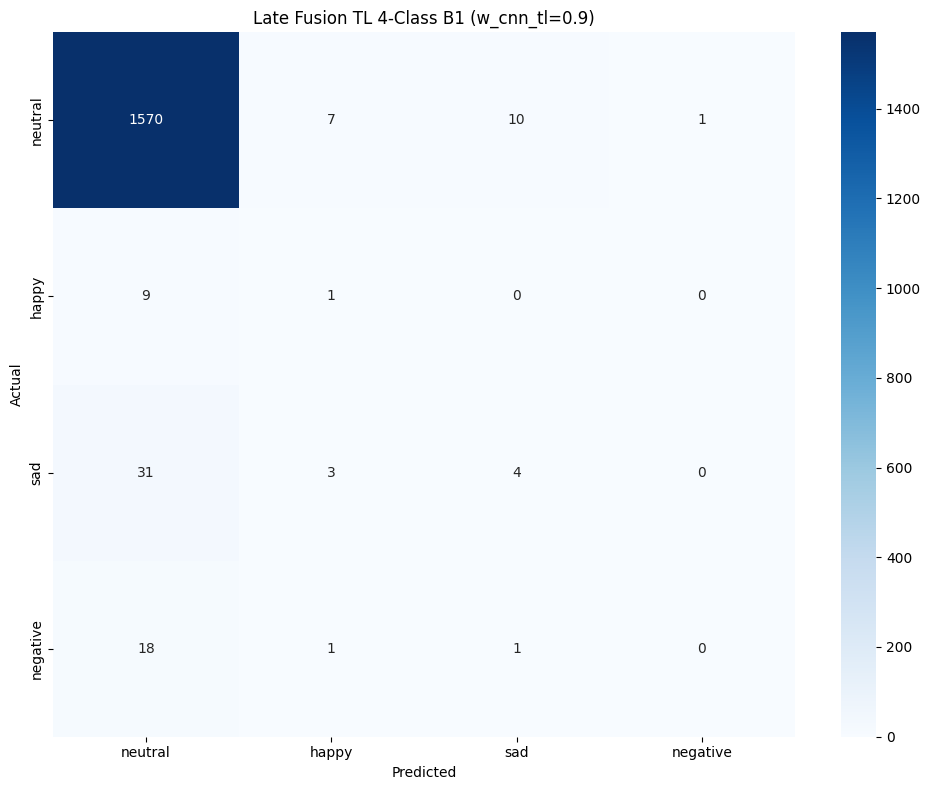


EVALUASI LATE FUSION TL 4-CLASS - Skenario B2 (w_cnn_tl=0.9)


Test Accuracy: 0.9390
Test Macro F1: 0.4423
Test Weighted F1: 0.9459

Classification Report:
              precision    recall  f1-score   support

     neutral       0.98      0.96      0.97      1588
       happy       0.12      0.20      0.15        10
         sad       0.38      0.55      0.45        38
    negative       0.16      0.25      0.20        20

    accuracy                           0.94      1656
   macro avg       0.41      0.49      0.44      1656
weighted avg       0.95      0.94      0.95      1656



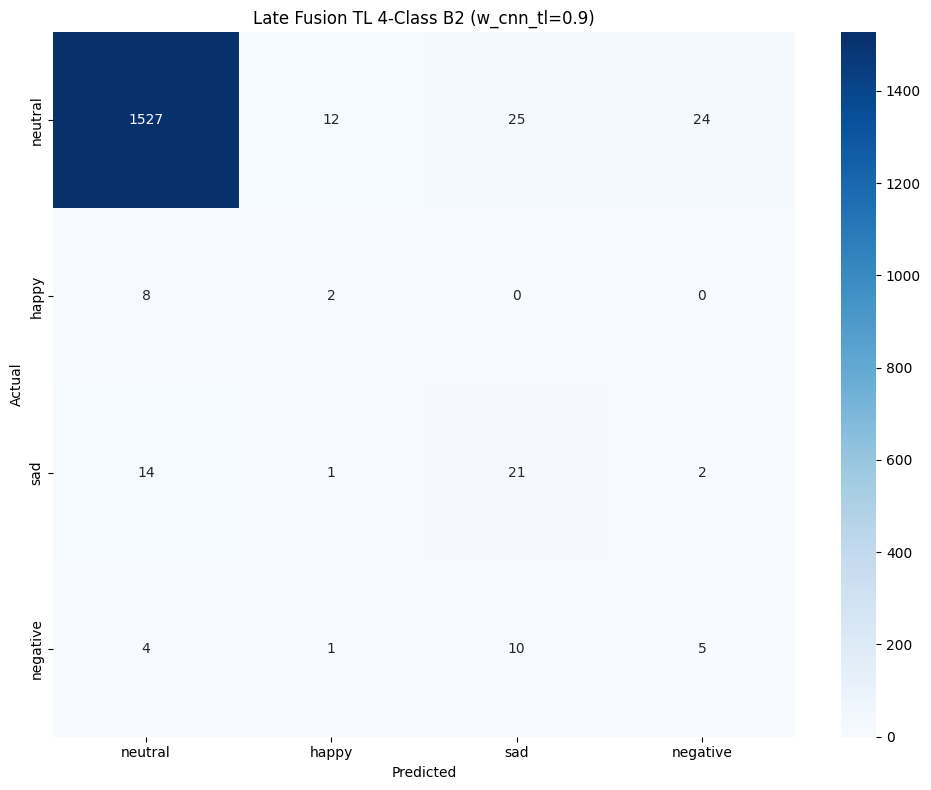


EVALUASI LATE FUSION TL 4-CLASS - Skenario B3 (w_cnn_tl=0.0)


Test Accuracy: 0.9438
Test Macro F1: 0.3941
Test Weighted F1: 0.9431

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.98      0.97      1588
       happy       0.11      0.30      0.16        10
         sad       0.77      0.26      0.39        38
    negative       0.06      0.05      0.05        20

    accuracy                           0.94      1656
   macro avg       0.48      0.40      0.39      1656
weighted avg       0.95      0.94      0.94      1656



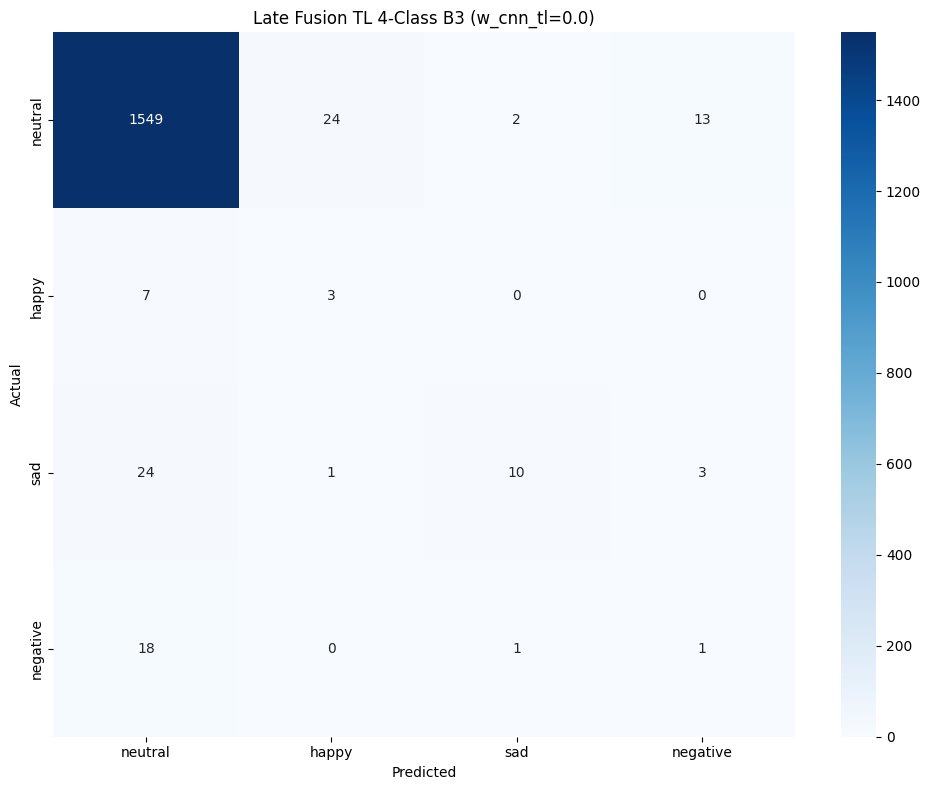

In [7]:
test_results = {}

for scenario_name, (cnn_model, fcnn_model) in models.items():
    best_w = grid_search_results[scenario_name]["best_weight_cnn"]

    print(f"\n{'='*60}")
    print(f"EVALUASI LATE FUSION TL 4-CLASS - Skenario {scenario_name} (w_cnn_tl={best_w:.1f})")
    print(f"{'='*60}")

    preds, labels, probs = late_fusion_predict(
        cnn_model, fcnn_model,
        test_img_loader, test_lm_loader,
        weight_cnn=best_w, device=device
    )

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(labels, preds, average="weighted", zero_division=0)
    cm = confusion_matrix(labels, preds)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Macro F1: {macro_f1:.4f}")
    print(f"Test Weighted F1: {weighted_f1:.4f}")
    print()
    print("Classification Report:")
    print(classification_report(labels, preds, target_names=EMOTIONS, zero_division=0))

    plot_confusion_matrix(cm, f"Late Fusion TL 4-Class {scenario_name} (w_cnn_tl={best_w:.1f})", emotions=EMOTIONS)

    test_results[scenario_name] = {
        "test_accuracy": acc,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "predictions": preds,
        "labels": labels,
        "confusion_matrix": cm,
        "optimal_weight_cnn": best_w,
    }

## 7. Results Comparison

In [8]:
# Summary table
print("=" * 75)
print("RINGKASAN LATE FUSION TRANSFER LEARNING 4-CLASS - 3 SKENARIO")
print("=" * 75)
print(f"{'Skenario':<15} {'w_cnn_tl':>8} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 75)
for name, r in test_results.items():
    w = r["optimal_weight_cnn"]
    print(f"LF-TL-{name:<9} {w:>8.1f} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

RINGKASAN LATE FUSION TRANSFER LEARNING 4-CLASS - 3 SKENARIO
Skenario        w_cnn_tl   Accuracy   Macro F1  Weighted F1
---------------------------------------------------------------------------
LF-TL-B1             0.9     0.9511     0.3046       0.9403
LF-TL-B2             0.9     0.9390     0.4423       0.9459
LF-TL-B3             0.0     0.9438     0.3941       0.9431


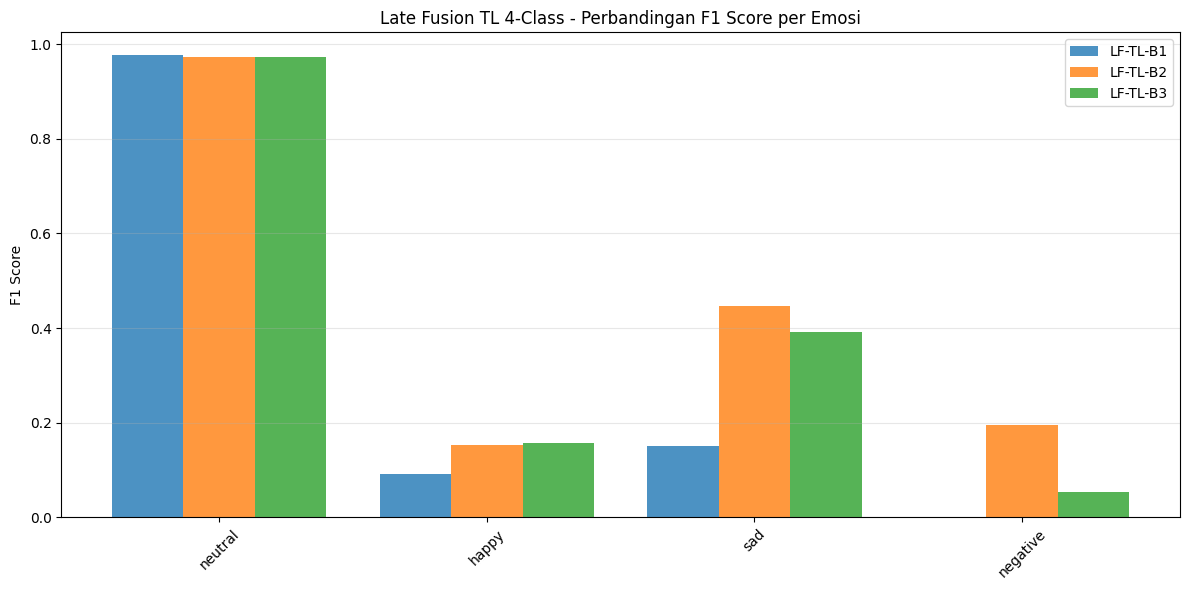

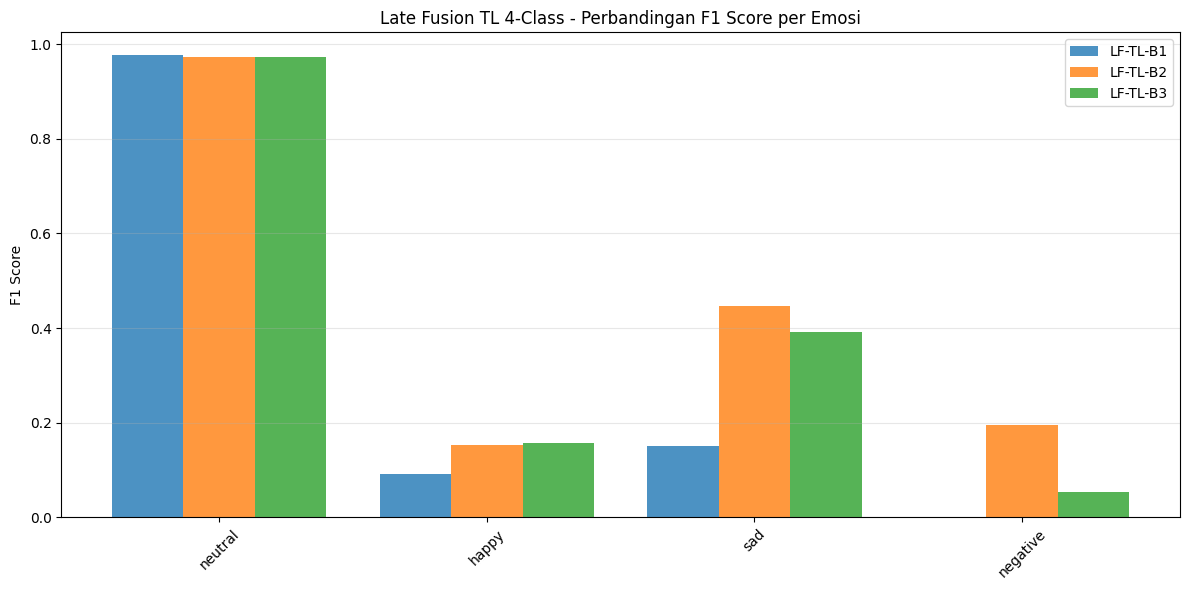

In [9]:
# Plot per-class F1 comparison
plot_results = {}
for name, r in test_results.items():
    plot_results[f"LF-TL-{name}"] = r

plot_per_class_f1(plot_results, "Late Fusion TL 4-Class - Perbandingan F1 Score per Emosi", emotions=EMOTIONS)

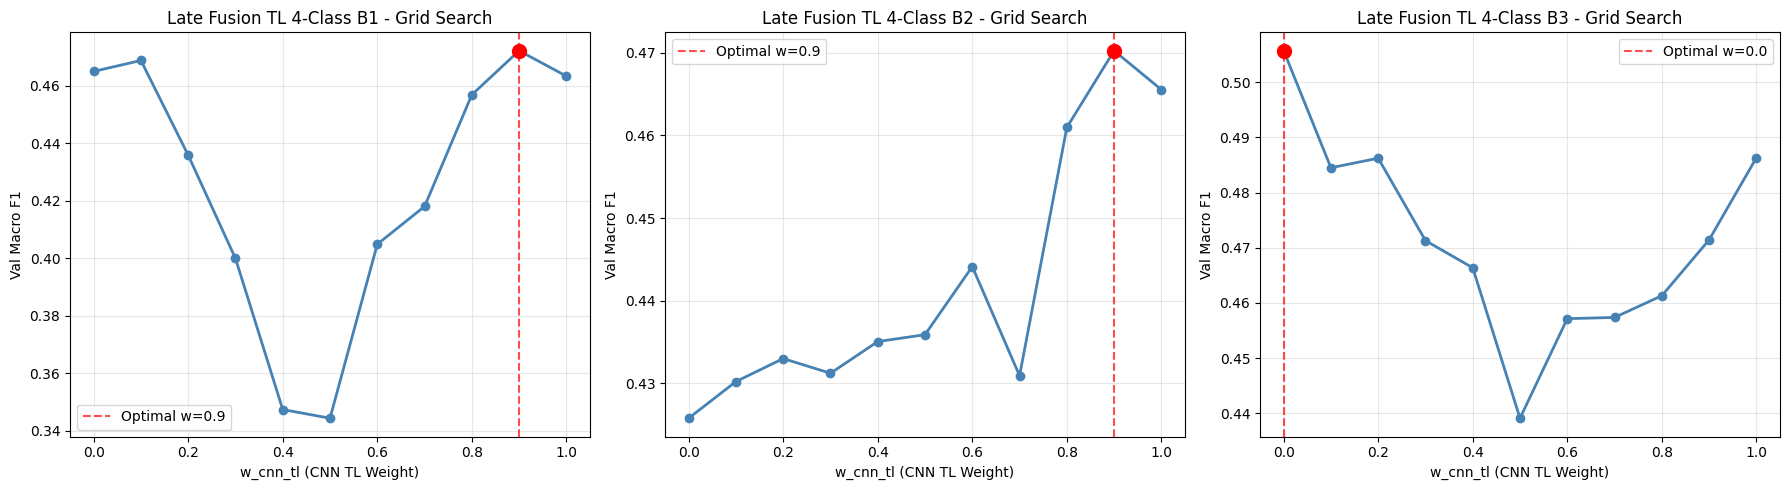

In [10]:
# Plot optimal weights per scenario
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (scenario_name, gs_result) in enumerate(grid_search_results.items()):
    ax = axes[idx]
    weights = [p[0] for p in gs_result["weight_f1_pairs"]]
    f1_scores = [p[1] for p in gs_result["weight_f1_pairs"]]
    best_w = gs_result["best_weight_cnn"]
    best_f1 = gs_result["best_val_f1"]

    ax.plot(weights, f1_scores, "o-", color="steelblue", linewidth=2, markersize=6)
    ax.axvline(x=best_w, color="red", linestyle="--", alpha=0.7,
               label=f"Optimal w={best_w:.1f}")
    ax.scatter([best_w], [best_f1], color="red", s=100, zorder=5)
    ax.set_xlabel("w_cnn_tl (CNN TL Weight)")
    ax.set_ylabel("Val Macro F1")
    ax.set_title(f"Late Fusion TL 4-Class {scenario_name} - Grid Search")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## 8. Save Results

In [11]:
# Save results to JSON
late_fusion_tl_results = {}
for name, r in test_results.items():
    late_fusion_tl_results[name] = {
        "optimal_weight_cnn": float(r["optimal_weight_cnn"]),
        "optimal_weight_fcnn": float(1 - r["optimal_weight_cnn"]),
        "val_macro_f1": float(grid_search_results[name]["best_val_f1"]),
        "test_accuracy": float(r["test_accuracy"]),
        "test_macro_f1": float(r["test_macro_f1"]),
        "test_weighted_f1": float(r["test_weighted_f1"]),
        "grid_search": [
            {"weight_cnn": float(w), "val_macro_f1": float(f1)}
            for w, f1 in grid_search_results[name]["weight_f1_pairs"]
        ],
    }

results_path = OUTPUT_DIR / "late_fusion_transfer_4class_results.json"
with open(results_path, "w") as f:
    json.dump(late_fusion_tl_results, f, indent=2)

print(f"Results saved to {results_path}")
print()
print(json.dumps(late_fusion_tl_results, indent=2))

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/4class/late_fusion_transfer/late_fusion_transfer_4class_results.json

{
  "B1": {
    "optimal_weight_cnn": 0.9,
    "optimal_weight_fcnn": 0.09999999999999998,
    "val_macro_f1": 0.47223616639186733,
    "test_accuracy": 0.9510869565217391,
    "test_macro_f1": 0.3045551615848715,
    "test_weighted_f1": 0.9402883917763376,
    "grid_search": [
      {
        "weight_cnn": 0.0,
        "val_macro_f1": 0.4650329814483239
      },
      {
        "weight_cnn": 0.1,
        "val_macro_f1": 0.46883704919661306
      },
      {
        "weight_cnn": 0.2,
        "val_macro_f1": 0.4358429412546866
      },
      {
        "weight_cnn": 0.3,
        "val_macro_f1": 0.39990469897011954
      },
      {
        "weight_cnn": 0.4,
        "val_macro_f1": 0.3472945164023726
      },
      {
        "weight_cnn": 0.5,
        "val_macro_f1": 0.3442822066659701
      },
      {
        "weight_cnn": 0.6,
        "val_macro_f1": 0.404848031